# Trabajo Práctico 1
**Visión por Computadora I — FIUBA**

Alumno: Cruz, C.

---
## Contenido
- **Parte 1:** Algoritmo White-Patch
- **Parte 2:** Histogramas como features

In [1]:
%matplotlib inline
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

BASE_PATH = Path(".")


---
## Parte 1 — Algoritmo White-Patch

El algoritmo White-Patch asume que el valor máximo de cada canal RGB en la imagen corresponde al color blanco bajo la iluminación de la escena. Normalizamos cada canal para compensar el color de la fuente de luz:

$$\hat{I}_c(u,v) = \frac{I_c(u,v)}{\max(I_c)} \times 255 \quad \text{para } c \in \{R, G, B\}$$

In [2]:
def white_patch(img_bgr: np.ndarray) -> np.ndarray:
    """
    Aplica el algoritmo White-Patch sobre una imagen BGR.
    Normaliza cada canal por su valor máximo para compensar
    el color de la fuente de iluminación.

    Parameters
    ----------
    img_bgr : np.ndarray
        Imagen de entrada en formato BGR (uint8).

    Returns
    -------
    np.ndarray
        Imagen corregida en formato BGR (uint8).
    """
    img_float = img_bgr.astype(np.float32)
    for c in range(3):
        max_val = img_float[:, :, c].max()
        if max_val > 0:
            img_float[:, :, c] = img_float[:, :, c] * (255.0 / max_val)
    return np.clip(img_float, 0, 255).astype(np.uint8)

In [3]:
def show_white_patch_result(img_path: Path) -> None:
    """Carga una imagen, aplica White-Patch y muestra la comparación."""
    img_bgr = cv.imread(str(img_path))
    if img_bgr is None:
        print(f'No se pudo cargar: {img_path}')
        return

    img_corrected = white_patch(img_bgr)

    # Convertir a RGB para matplotlib
    img_rgb = img_bgr[:, :, ::-1]
    img_corrected_rgb = img_corrected[:, :, ::-1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{img_path.name}', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_corrected_rgb)
    axes[1].set_title('White-Patch aplicado', fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

### 1.1 Resultados sobre las imágenes de prueba

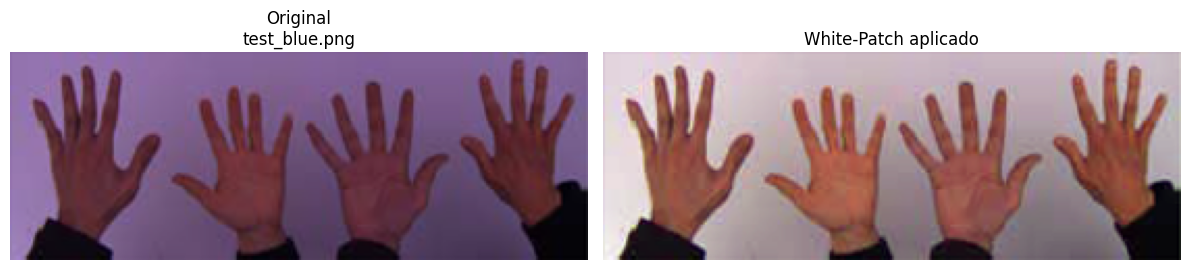

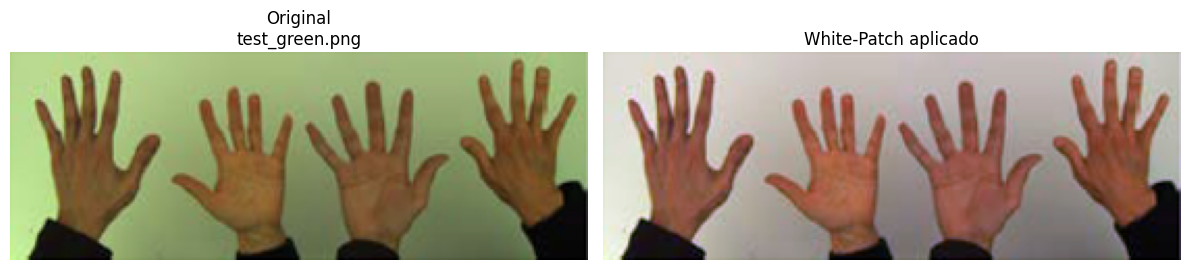

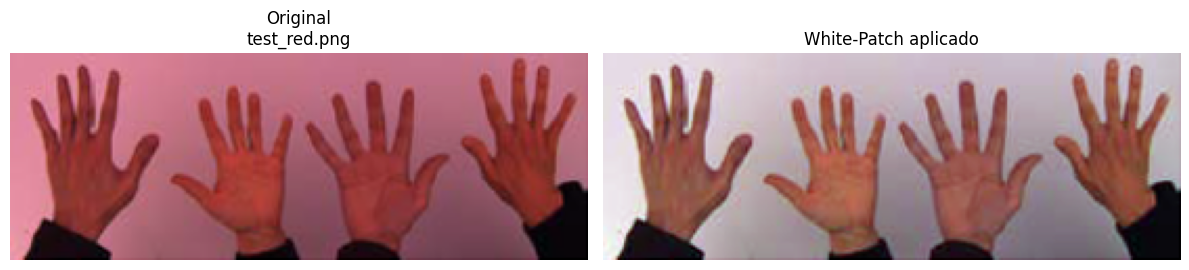

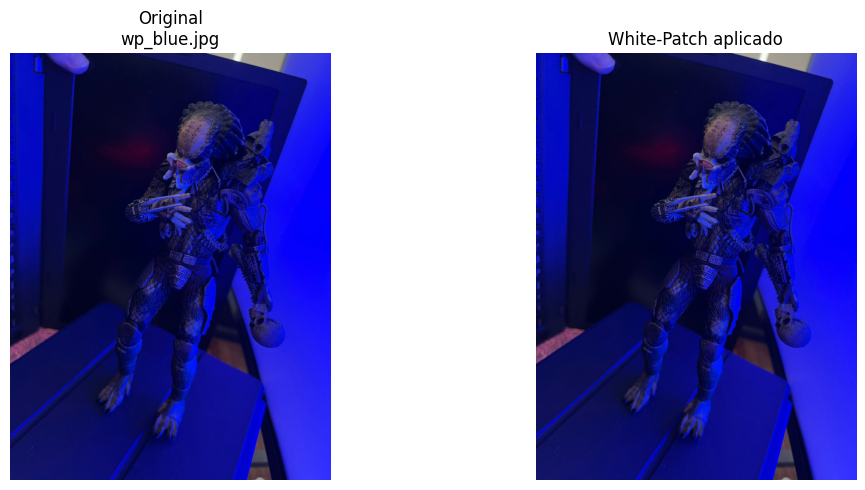

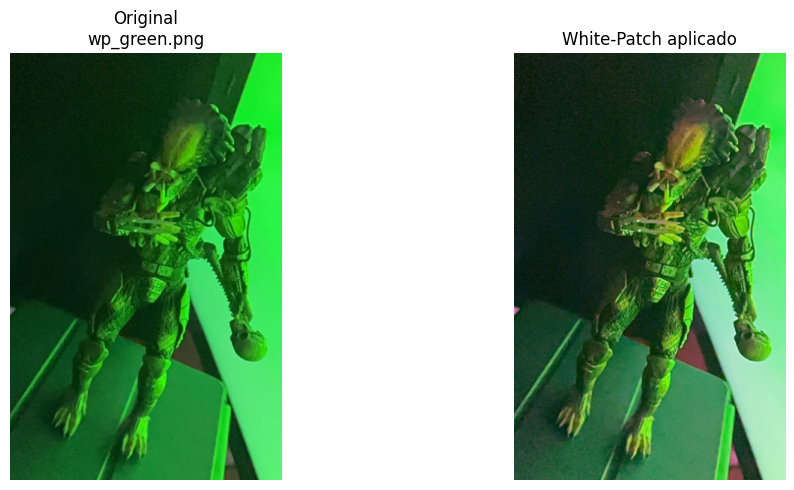

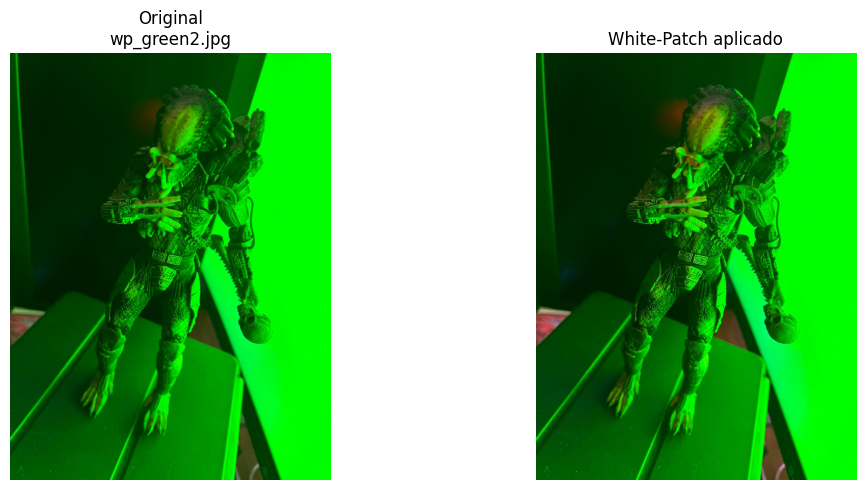

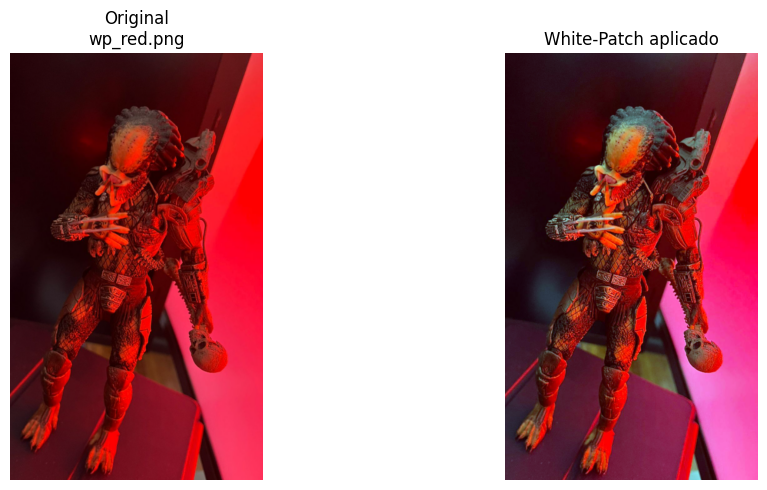

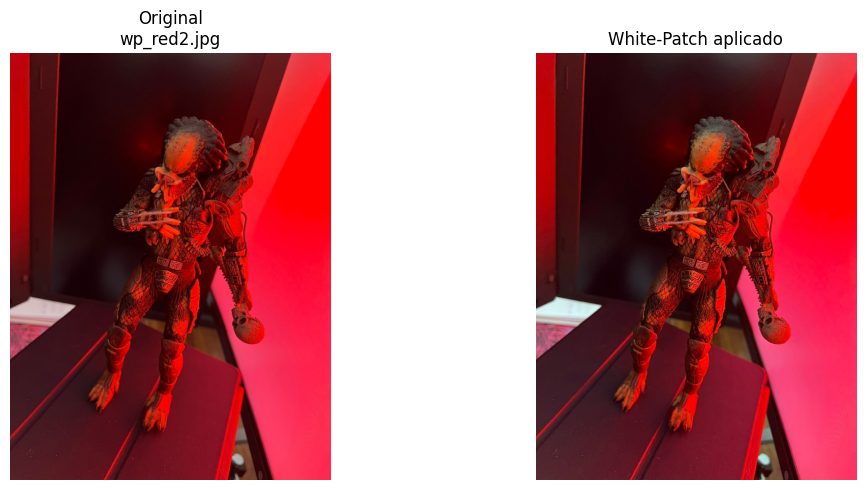

In [4]:
wp_path = BASE_PATH / 'white_patch'
wp_images = sorted(wp_path.iterdir())

for img_path in wp_images:
    show_white_patch_result(img_path)

### 1.2 Análisis de fallas del algoritmo White-Patch

El algoritmo White-Patch presenta las siguientes **limitaciones**:

1. **Sensibilidad a píxeles saturados o sobreexpuestos:** Si un solo píxel tiene un valor extremadamente alto en algún canal (ruido, reflejos especulares, outliers), el máximo de ese canal se verá dominado por ese píxel y la normalización sobre-corregirá el canal completo, produciendo una imagen con colores incorrectos.

2. **Asunción bimodal de la escena:** El algoritmo presupone que la escena contiene algún objeto blanco (o casi blanco). Si la escena **no tiene blancos** —por ejemplo, una foto de un atardecer o una escena completamente monocromática— la corrección produce colores artificiales y erróneos.

3. **Iluminaciones múltiples:** En escenas con más de una fuente de luz de distinto color, el algoritmo no puede compensar correctamente ya que asume una única temperatura de color global.

4. **Invarianza a escala pero no a traslación:** Las coordenadas cromáticas resultantes son invariantes a cambios de contraste (escala), pero si hay un offset de brillo (bias), el algoritmo falla porque el máximo ya no refleja fielmente el color de la iluminación.

**Verificación visual:** En las imágenes `test_*` se puede observar el comportamiento ideal, mientras que en las imágenes `wp_*` se pueden apreciar casos donde el algoritmo introduce artefactos de color.

---
## Parte 2 — Histogramas como features

Leemos `img1_tp.png` e `img2_tp.png` en escala de grises, graficamos y comparamos sus histogramas.

img1 shape: (288, 287) | dtype: uint8
img2 shape: (288, 287) | dtype: uint8


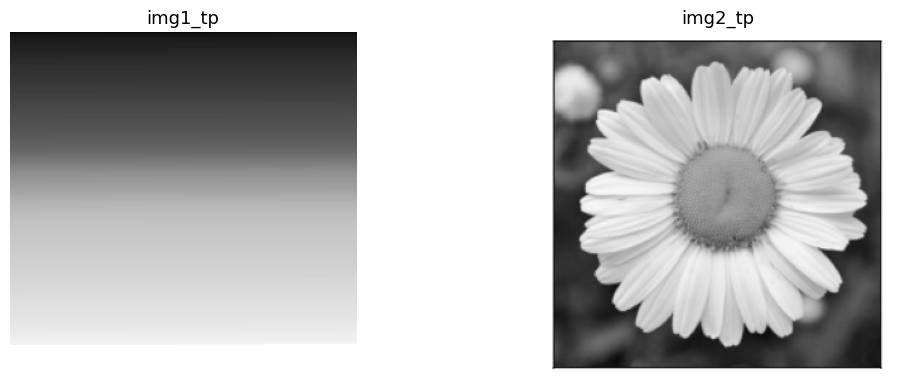

In [5]:
img1 = cv.imread(str(BASE_PATH / 'img1_tp.png'), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(str(BASE_PATH / 'img2_tp.png'), cv.IMREAD_GRAYSCALE)

print(f'img1 shape: {img1.shape} | dtype: {img1.dtype}')
print(f'img2 shape: {img2.shape} | dtype: {img2.dtype}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp', fontsize=13)
axes[0].axis('off')
axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp', fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 2.1 Cálculo y visualización de histogramas

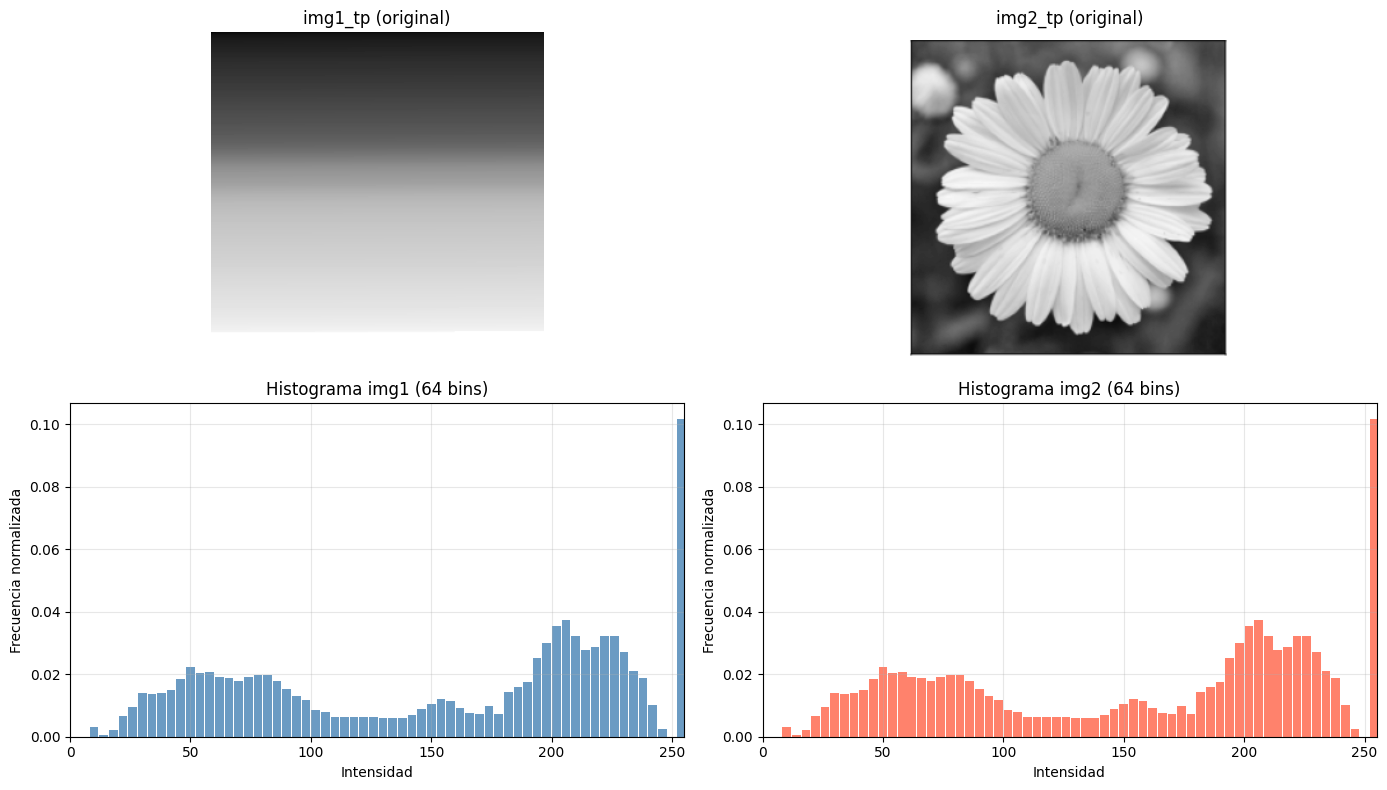

In [6]:
# Elección de bins: 64 bins dan una granularidad suficiente para capturar
# la distribución de intensidades sin caer en el ruido bin a bin de 256 bins.
N_BINS = 64

hist1, bins1 = np.histogram(img1.ravel(), bins=N_BINS, range=(0, 256))
hist2, bins2 = np.histogram(img2.ravel(), bins=N_BINS, range=(0, 256))

# Normalizar para comparar independientemente del tamaño de la imagen
hist1_norm = hist1 / hist1.sum()
hist2_norm = hist2 / hist2.sum()

bin_centers = (bins1[:-1] + bins1[1:]) / 2

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Imágenes
axes[0, 0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('img1_tp (original)', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('img2_tp (original)', fontsize=12)
axes[0, 1].axis('off')

# Histogramas
axes[1, 0].bar(bin_centers, hist1_norm, width=(256/N_BINS)*0.9, color='steelblue', alpha=0.8)
axes[1, 0].set_title(f'Histograma img1 ({N_BINS} bins)', fontsize=12)
axes[1, 0].set_xlabel('Intensidad')
axes[1, 0].set_ylabel('Frecuencia normalizada')
axes[1, 0].set_xlim(0, 255)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].bar(bin_centers, hist2_norm, width=(256/N_BINS)*0.9, color='tomato', alpha=0.8)
axes[1, 1].set_title(f'Histograma img2 ({N_BINS} bins)', fontsize=12)
axes[1, 1].set_xlabel('Intensidad')
axes[1, 1].set_ylabel('Frecuencia normalizada')
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Comparación superpuesta

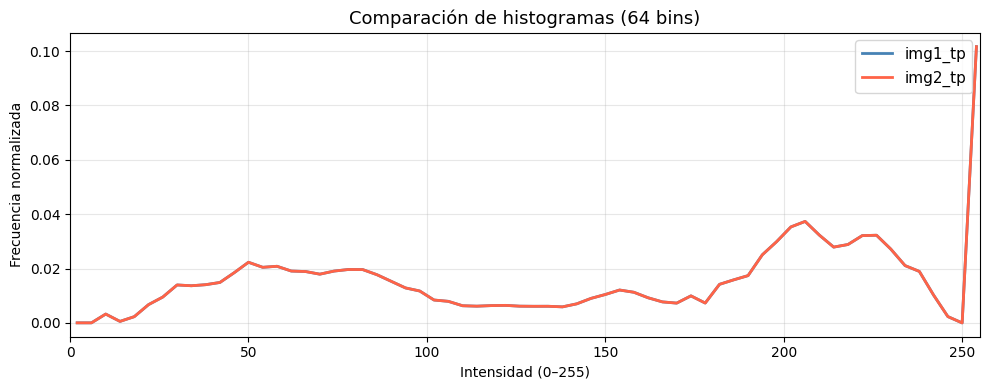

img1 — media: 154.81 | std: 75.34 | min: 2 | max: 255
img2 — media: 154.81 | std: 75.34 | min: 2 | max: 255


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bin_centers, hist1_norm, color='steelblue', linewidth=2, label='img1_tp')
ax.plot(bin_centers, hist2_norm, color='tomato',    linewidth=2, label='img2_tp')
ax.set_title(f'Comparación de histogramas ({N_BINS} bins)', fontsize=13)
ax.set_xlabel('Intensidad (0–255)')
ax.set_ylabel('Frecuencia normalizada')
ax.set_xlim(0, 255)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas básicas
print(f'img1 — media: {img1.mean():.2f} | std: {img1.std():.2f} | min: {img1.min()} | max: {img1.max()}')
print(f'img2 — media: {img2.mean():.2f} | std: {img2.std():.2f} | min: {img2.min()} | max: {img2.max()}')

### 2.3 Análisis y conclusiones

**Observaciones del histograma:**

- `img1_tp` y `img2_tp` presentan distribuciones de intensidad notablemente diferentes: una tiende a concentrar los píxeles en el rango oscuro/medio y la otra en el rango claro, lo que se refleja en diferencias de media y desviación estándar.
- El histograma permite diagnosticar el rango dinámico: una imagen bien expuesta ocupa la mayor parte del rango (0–255), mientras que una imagen de bajo contraste estará comprimida en una franja estrecha.

**¿Son los histogramas útiles como features para clasificación/detección?**

**Sí, con condiciones.** El histograma de intensidades es un descriptor **global** compacto (64 valores en este caso) que captura la distribución tonal de la imagen. Es útil cuando:
- Las clases tienen distribuciones de intensidad características y reproducibles (ej: imágenes de día vs. noche, tejidos médicos, texturas industriales).
- La iluminación es controlada o normalizada previamente.

**Limitaciones como feature:**
- **No tiene información espacial:** dos imágenes completamente distintas pueden tener histogramas idénticos si tienen la misma distribución de tonos.
- **Sensible a cambios de iluminación:** variaciones en brillo o contraste desplazan o escalan el histograma, afectando la discriminación entre clases.
- Para modelos de clasificación robustos, conviene combinar el histograma con descriptores locales (HOG, LBP) o normalizarlo (ecualización) antes de usarlo como feature.

**Elección de bins:** Se eligieron **64 bins** como balance entre resolución (poder discriminar distribuciones distintas) y compacidad (evitar overfitting a ruido en el histograma con 256 bins, donde muchos bins adyacentes capturan básicamente el mismo fenómeno).